In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent / "src"))

import config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(config.DB_LOCATION)

C:\Users\bnpar\AppData\Local\Temp\ipykernel_15948\2957537646.py:13: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


In [2]:
#reduced dataframe
red_df = df[['Name', 'Sex', 'Division', 'BodyweightKg', 'WeightClassKg','Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg', 'Date', 'Sanctioned', 'Equipment', 'Event']]

### Cleaning dataset



In [3]:
def get_mixed_cols(dataframe):
    all_types_count = {} #nested dict w column heading as outer key. Inner key-value pairs are data types/how many entries with that datatyoe
    for col in dataframe.columns:
        col_types = dataframe[col].map(type)   #applies type(x) to every x in the column so you get series ['string', 'string', 'float'....]
        all_types_count[col] = col_types.value_counts().to_dict()
    mixed_type_cols = []
    for col in all_types_count:
        no_types = len(all_types_count[col].values())
        #we are only appending columns with mixed data types
        if no_types > 1:
            mixed_type_cols.append(col)
    return mixed_type_cols

mixed_cols = get_mixed_cols(red_df)
print(mixed_cols)

['Division', 'WeightClassKg']


In [4]:
#checking if all the floats are because of NaN
for col in mixed_cols:
    mask = red_df[col].map(type) == float
    float_col = red_df.loc[mask, col]
    float_col = float_col.dropna()
    print(float_col)

Series([], Name: Division, dtype: object)
Series([], Name: WeightClassKg, dtype: object)


- All float datatypes are because of NaN entries in WeightClassKg or Division. Want to drop any entries where we dont know what the weight class is.
- Are okay with not knowing the Division i.e. whether the lifter is a Junior or Open lifter for now, as a lifter of any age can set an Open WR.
- Chosen to drop any unsanctioned meets.
- Flitered for Raw powerlifting only (specified in 'Equipment' column).
- Turned dates into datetime objects.
- Filtering for full power events (e.g. excluding bench only comps)

In [5]:
red_df = red_df[red_df['Equipment'] == 'Raw'].copy()
red_df['Date'] = pd.to_datetime(red_df['Date'] , format = '%Y-%m-%d')
red_df['Year'] = red_df['Date'].dt.year
red_df = red_df.dropna(axis = 'rows', subset = ['WeightClassKg'])
unsanctioned = red_df[red_df['Sanctioned'] == 'No'].index.to_list()
red_df = red_df.drop(labels = unsanctioned, axis = 'index')
full_power = red_df[red_df['Event'] == 'SBD'].copy()
#bench_only = red_df[red_df['Event']== 'B'].copy()


Next we flag entries in the dataset that exceed the current world official world record. Note that the total being more than the official WR does not necessarily mean the entry is incorrect. Official WRs can only be set at international meets and lifters may have exceeded this at national or local events, without setting a new official WR.

Also note that the 53kg and 43kg in the men's and women's categories respectively are only in the Junior age division.


In [6]:
m_off_wr_totals = {'53': 559, '59': 669.5, '66': 770, '74': 843, '83': 890, '93': 918, '105': 975.5, '120': 978.5, '120+': 1152.5}
f_off_wr_totals = {'43': 349.5, '47': 435, '52': 482.5, '57': 520, '63': 565, '69': 628, '76': 620, '84': 647, '84+': 737.5}

exceeds_wr = pd.DataFrame(columns = red_df.columns.to_list())

for weight_class in m_off_wr_totals:
    weight_class_entries = full_power[(full_power['WeightClassKg'] == weight_class) & (full_power['Sex'] == 'M')].copy()
    exceeds_class_wr = weight_class_entries[weight_class_entries['TotalKg']>m_off_wr_totals[weight_class] ]
    exceeds_wr = pd.concat([exceeds_wr, exceeds_class_wr])

for weight_class in f_off_wr_totals:
    weight_class_entries = full_power[(full_power['WeightClassKg'] == weight_class) & (full_power['Sex'] == 'F')].copy()
    exceeds_class_wr = weight_class_entries[weight_class_entries['TotalKg']>f_off_wr_totals[weight_class]]
    exceeds_wr = pd.concat([exceeds_wr, exceeds_class_wr])
    
exceeds_wr

C:\Users\bnpar\AppData\Local\Temp\ipykernel_15948\1112979477.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exceeds_wr = pd.concat([exceeds_wr, exceeds_class_wr])


,Name,Sex,Division,BodyweightKg,WeightClassKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,TotalKg,Date,Sanctioned,Equipment,Event,Year
891163,Sergey Fedosienko,M,Open,58.50,59,226.5,170.5,273.0,670.0,2015-12-24,Yes,Raw,SBD,2015
907319,Sergey Fedosienko,M,Open,59.00,59,228.0,167.5,275.0,670.5,2020-03-18,Yes,Raw,SBD,2020
1242982,Joseph Borenstein,M,MR-O,82.91,83,305.0,218.0,377.0,900.0,2025-04-03,Yes,Raw,SBD,2025
1237528,William Ball #2,M,MR-Jr,92.15,93,322.5,222.5,375.0,920.0,2025-09-27,Yes,Raw,SBD,2025
1243024,Jonathan Cayco,M,MR-O,92.85,93,310.0,252.0,357.5,919.5,2025-04-03,Yes,Raw,SBD,2025
1243068,Anthony McNaughton,M,MR-O,103.74,105,365.0,245.0,369.0,979.0,2025-04-03,Yes,Raw,SBD,2025
1241212,Bobb Matthews,M,MR-O,110.75,120,367.5,247.5,395.5,1010.5,2025-11-22,Yes,Raw,SBD,2025
1243132,Rondel Hunte,M,MR-G,119.58,120,375.0,260.0,375.0,1010.0,2025-04-03,Yes,Raw,SBD,2025
1241213,Jesus Olivares,M,MR-O,182.40,120+,478.5,265.0,410.0,1153.5,2025-11-22,Yes,Raw,SBD,2025
937711,Joy Nnamani,F,FR-O,56.70,57,185.0,100.0,235.5,520.5,2025-12-05,Yes,Raw,SBD,2025


All entries that exceed the current world record are credible and correct against the results from those meets.

### Dealing with weight class changes

Next we look for weight classes in the df which are not the weight classes that the IPF and its affiliates currrently use. 


In [7]:
current_f_class_mask = (full_power['WeightClassKg'].isin(f_off_wr_totals.keys())) & (full_power['Sex'] == 'F')
current_m_class_mask = (full_power['WeightClassKg']).isin(m_off_wr_totals.keys()) & (full_power['Sex'] == 'M')

invalid_class_entries = full_power[(~current_f_class_mask) & (~current_m_class_mask) ].copy()
f_invalid_class_entries = full_power[~current_f_class_mask].copy()
m_invalid_class_entries = full_power[~current_m_class_mask].copy()

current_f_classes = full_power[current_f_class_mask].copy()
current_m_classes = full_power[current_m_class_mask].copy()

f'{(len(invalid_class_entries)/len(full_power))*100 :.2f}% of the dataset is entries that do not match the IPF\'s current weight classes'

"7.08% of the dataset is entries that do not match the IPF's current weight classes"

Given that only 7.08% of the dataset are entries which do not match the IPF's current weight classes, these will be excluded from the dataset. Need to understand the impact of this so will determine when the weight class changes took place. There is no official documentation that describes the weight class changes. So need to look at the dataset to determine when these took place.

In [8]:
f_annual_per_current_class = current_f_classes.groupby(['WeightClassKg', 'Year']).size().reset_index(name = 'AnnualClassParticipation')
total_annual = full_power[full_power['Sex']== 'F'].groupby('Year').size().reset_index(name = 'AnnualParticipation') #total annual participation across weight classes (including historic and mistaken weight classes) 

f_annual_per_current_class = f_annual_per_current_class.merge(total_annual, on = 'Year', how = 'left', validate = 'm:1') 

#now we want annual participation excl incurrent classes
current_class_share = f_annual_per_current_class.groupby('Year')['AnnualClassParticipation'].sum().reset_index(name = 'CurrentClassParticipation')

f_annual_per_current_class = f_annual_per_current_class.merge(current_class_share, how = 'left', on = 'Year')
f_annual_per_current_class['CurrentClassShare'] = (f_annual_per_current_class['CurrentClassParticipation']/f_annual_per_current_class['AnnualParticipation'])*100

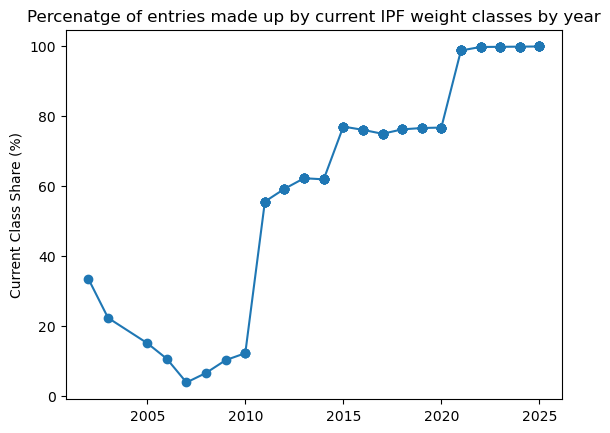

In [9]:
df = f_annual_per_current_class.copy() 
df_sorted = df.sort_values('Year')
plt.plot(df_sorted['Year'],df_sorted['CurrentClassShare'], marker = 'o')
plt.title("Percenatge of entries made up by current IPF fweight classes by year")
plt.ylabel("Current Class Share (%)")
plt.show()

Can see that weight classes changed between 2020 and 2021. Need to detect what that weight class shift was

In [10]:
old_struct_years = [2015, 2016, 2017, 2018, 2019, 2020]
new_struct_years = [2021, 2022, 2023,2024, 2025]
all_years = old_struct_years + new_struct_years
f = full_power.loc[(full_power['Sex'] == 'F') & (full_power['Year']).isin(all_years)]
#possible_classes = f['WeightClassKg'].unique()

f_class_participation = f.groupby(['WeightClassKg', 'Sex', 'Year']).size().reset_index(name = 'AnnualClassParticipation')
f_total_participation = f_class_participation.groupby('Year')['AnnualClassParticipation'].sum().reset_index(name = 'AnnualParticipation')

f_class_participation = f_class_participation.merge(f_total_participation, on = 'Year', how = 'left', validate = 'm:1')
f_class_participation['ClassShare'] = (f_class_participation['AnnualClassParticipation']/ f_class_participation['AnnualParticipation'])*100



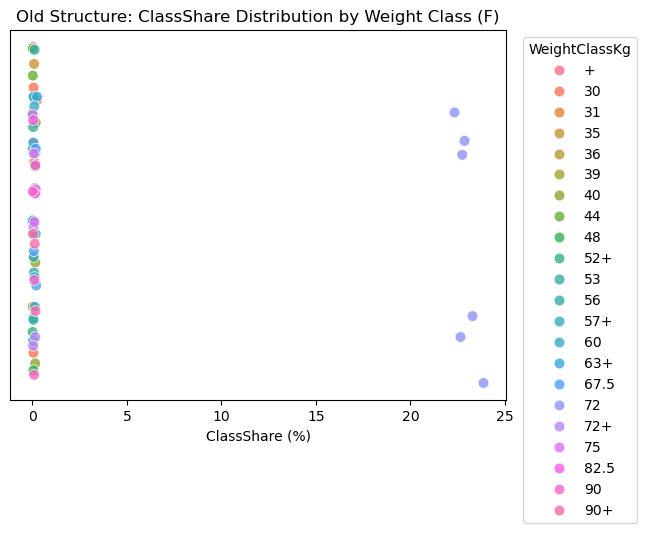

In [11]:
#looking at class participation in weight classes that are NOT the current classes 
old = f_class_participation.loc[f_class_participation['Year'].isin(old_struct_years)]
#old = old.sort_values('ClassShare', ascending = False)
old_copy = old.loc[~old["WeightClassKg"].isin(f_off_wr_totals.keys())].copy() 
rng = np.random.default_rng(42)
old_copy["y_jitter"] = rng.uniform(-0.4, 0.4, size=len(old_copy))

plt.figure()
sns.scatterplot(
    data=old_copy,
    x="ClassShare",
    y="y_jitter",
    hue="WeightClassKg",
    alpha=0.8,
    s=60
)

plt.xlabel("ClassShare (%)")
plt.yticks([])
plt.ylabel("")
plt.title("Old Structure: ClassShare Distribution by Weight Class (F)")
plt.legend(title="WeightClassKg", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Can see most classes that are not current IPF weight classes are clustered around 0. Excepton of one weight class which looks like 72kg class. Confirm this as colours can be unclear.


In [12]:
old_copy[old_copy['ClassShare']>20]

,WeightClassKg,Sex,Year,AnnualClassParticipation,AnnualParticipation,ClassShare,y_jitter
148,72,F,2015,2092,9236,22.650498,-0.288198
149,72,F,2016,3086,13254,23.283537,-0.240073
150,72,F,2017,4079,17095,23.860778,-0.394110
151,72,F,2018,4373,19584,22.329453,0.229540
152,72,F,2019,4858,21363,22.740252,0.131881
153,72,F,2020,1668,7296,22.861842,0.164132


Can see 72kg class was present in 2015-2020. Now need to check which classes weren't present in 2015-2020 that are present in 2021-2025.

In [13]:
current_w_cl = list(f_off_wr_totals.keys())
candidate_old_wcl = current_w_cl + ['72']

#see which weight classes dropped off between 2020 and 2021


relevant_years = (f_class_participation.loc[f_class_participation["Year"].isin([2020, 2021]) & (f_class_participation['WeightClassKg'].isin(candidate_old_wcl)),["WeightClassKg", "Year", "ClassShare"]])
change_in_class = relevant_years.pivot(index = 'WeightClassKg', columns = 'Year', values = 'ClassShare')
change_in_class = change_in_class.rename(columns = {2020: "ClassShare_2020", 2021: "ClassShare_2021"})
change_in_class["Absolute_Change"] = change_in_class['ClassShare_2021'] - change_in_class['ClassShare_2020']

change_in_class = change_in_class.sort_values("Absolute_Change", ascending=False)
change_in_class

Year,ClassShare_2020,ClassShare_2021,Absolute_Change
WeightClassKg,,,
69,0.013706,16.020693,16.006987
76,0.013706,14.460503,14.446796
43,0.753838,0.615865,-0.137973
47,3.865132,3.498111,-0.367020
84+,12.595943,12.153063,-0.442880
57,15.008224,14.288060,-0.720163
52,8.854167,7.874856,-0.979310
63,20.175439,19.182132,-0.993307
84,15.296053,10.494334,-4.801719


Can see that 69kg and 76kg classes had sharp increase from negligible presence (likely caused by data entry errors) to making up significant class share. 72kg class had the opposite (as it was removed as weight class).

In [14]:
old_classes = ['43', '47', '52', '57', '63', '72', '84', '84+']
new_classes = ['43', '47', '52', '57', '63', '69','76', '84', '84+']

In [28]:
f_cleaned_classes = f.loc[
    (f['Year'].isin(old_struct_years)& f['WeightClassKg'].isin(old_classes))|
    (f['Year'].isin(new_struct_years)& f['WeightClassKg'].isin(new_classes))
    ]

In [33]:
f'{(len(full_power_rel_years[full_power_rel_years['Sex']=='F'])/len(full_power[full_power['Sex']=='F']))*100:.2f}% of f IPF entries are in the last 10 years'

'93.99% of f IPF entries are in the last 10 years'